# Notebook 03: Topic Clustering

## Goal

Discover latent topic structure in MedQA questions using BERTopic.

The classifier in notebook 02 assigns a broad specialty label (19 classes) to each question.
Clustering goes one level deeper: it finds fine-grained topic groups *within* the question bank
without using any labels, driven entirely by the question text. These topic assignments are
used at RAG inference time to retrieve topically similar questions as few-shot context.

## Research Question Re-Test
A2 found TF-IDF + GMM/EM (kappa = 0.418) as the frequency-based champion and
PubMedBERT + Spectral Clustering as the state-of-the-art champion on a highly overlapping
corpus (pairwise similarity ~0.95). With MedMCQA showing 0.72 mean inter-category similarity,
do the A2 champions hold, or does the lower overlap change the ranking?

## Evaluation protocol (A2 Methodology)
- Primary metric   : Cohen's kappa (topic vs specialty label agreement)
- Secondary metrics: Silhouette score, Topic Coherence C_v
- A2 baselines     : TF-IDF + GMM (kappa 0.418), Embeddings + Spectral
- Primary method   : BERTopic (HDBSCAN-based, automatic topic count)

<div class="alert alert-block alert-info">
<b style="font-size: 1.2em;">ⓘ Note</b>

BERTopic determines K automatically from the data via HDBSCAN. The only parameter we set is `min_cluster_size` which controls granularity.
</div>

## Output
```
models/clustering/
  bertopic_model/              # saved BERTopic model
  medqa_with_topics.parquet    # MedQA with topic assignments
  config.json                  # evaluation results
```

## 0. Environment Setup

In [1]:
import sys
import os
import shutil
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    if not Path('/content/emma').exists():
        !git clone https://github.com/jaxendutta/emma.git
    os.chdir('/content/emma')
    !pip install -e . -q
    !pip install faiss-cpu sentence-transformers bertopic gensim umap-learn hdbscan -q
    
    drive.mount('/content/drive')
    DRIVE_CLF = Path('/content/drive/MyDrive/emma/models/classifier')
    DRIVE_OUT = Path('/content/drive/MyDrive/emma/models/clustering')
    DRIVE_OUT.mkdir(parents=True, exist_ok=True)

    # Restore classifier outputs from Drive
    local_clf = Path('/content/emma/models/classifier')
    local_clf.mkdir(parents=True, exist_ok=True)
    if DRIVE_CLF.exists():
        for f in DRIVE_CLF.glob('*'):
            shutil.copy(f, local_clf / f.name)

import json
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import SpectralClustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import cohen_kappa_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder

from src.cluster import evaluate_topics, format_eval, get_topic_words, topic_specialty_alignment
from src.data import REPO_ROOT
from src.vectorstore import BIOMEDICAL_MODEL, embed_texts, load_embedding_model

CLUSTERING_DIR = REPO_ROOT / 'models' / 'clustering'
CLUSTERING_DIR.mkdir(parents=True, exist_ok=True)
CLASSIFIER_DIR = REPO_ROOT / 'models' / 'classifier'

print(f'Environment    : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Repo root      : {REPO_ROOT}')
print(f'Clustering dir : {CLUSTERING_DIR}')

Environment    : Local
Repo root      : C:\Projects\emma
Clustering dir : C:\Projects\emma\models\clustering


## 1. Data Loading

Load MedQA with specialty labels from notebook 02.
These labels serve as ground truth for Cohen's kappa evaluation.

In [2]:
medqa_path = CLASSIFIER_DIR / 'medqa_with_specialty.parquet'
if not medqa_path.exists():
    raise FileNotFoundError(
        f'{medqa_path} not found.\n'
        'Run notebook 02_classification.ipynb first.'
    )

medqa = pd.read_parquet(medqa_path)
docs        = medqa['question'].tolist()
specialties = medqa['specialty'].tolist()

le = LabelEncoder()
y  = le.fit_transform(specialties)
K  = medqa['specialty'].nunique()   # data-driven K for baselines

print(f'Questions   : {len(docs):,}')
print(f'Specialties : {K}  (used as K for GMM/Spectral baselines)')
display(medqa['specialty'].value_counts().reset_index())

Questions   : 12,723
Specialties : 19  (used as K for GMM/Spectral baselines)


,specialty,count
0,Internal Medicine,4206
1,Pathology,2900
2,Surgery,977
3,Obstetrics & Gynaecology,863
4,Psychiatry,720
5,Microbiology,560
6,Pharmacology,516
7,Pediatrics,492
8,Public Health,343
9,Anatomy,250


## 2. Pre-Compute Embeddings

All three methods use the same embedding space for a fair comparison.
Pre-computing here avoids re-embedding for each method.

In [3]:
# USE_FAST_MODEL=True for local CPU (~10 min); False for Qwen3 on GPU
USE_FAST_MODEL = True
EMB_MODEL = 'all-MiniLM-L12-v2' if USE_FAST_MODEL else BIOMEDICAL_MODEL

print(f'Embedding model: {EMB_MODEL}')
print(f'Documents      : {len(docs):,}')
emb_model  = load_embedding_model(EMB_MODEL)
embeddings = embed_texts(docs, emb_model, batch_size=32)
print(f'Embedding matrix: {embeddings.shape}')

Embedding model: all-MiniLM-L12-v2
Documents      : 12,723


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Vectorstore] Embedding model: sentence-transformers/all-MiniLM-L12-v2  (dtype=torch.float32, device=cpu)


Embedding chunks: 100%|██████████| 12,723/12,723 [04:17<00:00, 49.41chunk/s]

Embedding matrix: (12723, 384)


## 3. A2 Baseline 1: TF-IDF + GMM

The A2 frequency-based champion (kappa = 0.418 on PubMed AI corpus).
Reproduced as a lower-bound reference point.

<div class="alert alert-block alert-info">
<b style="font-size: 1.2em;">ⓘ Note</b>

K is set to the number of unique specialties (19, derived from the data) so kappa is comparable across methods. BERTopic determines K automatically in section 5.
</div>

In [4]:
print('Fitting TF-IDF...')
tfidf   = TfidfVectorizer(max_features=10_000, sublinear_tf=True, min_df=2)
X_tfidf = tfidf.fit_transform(docs)
print(f'TF-IDF matrix (sparse): {X_tfidf.shape}')

# Reduce to 200 dims via LSA (Latent Semantic Analysis) before GMM
# Full covariance GMM on 13k dims is O(d^3) per iteration -- intractable
# 200 dims captures ~90% of variance and makes GMM feasible
print('Reducing to 200 dims via LSA (TruncatedSVD)...')
svd = TruncatedSVD(n_components=200, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)
explained = svd.explained_variance_ratio_.sum()
print(f'LSA matrix: {X_lsa.shape}  ({explained:.1%} variance explained)')

print(f'\nFitting GMM (K={K}, covariance=diag)...')
gmm = GaussianMixture(
    n_components=K,
    covariance_type='diag',   # O(d) not O(d^3) -- tractable at any dim
    max_iter=100,
    random_state=42,
    verbose=2,
    verbose_interval=10,
)
gmm.fit(X_lsa)
gmm_labels = gmm.predict(X_lsa)

res_gmm = evaluate_topics(
    topic_labels=gmm_labels,
    specialty_labels=specialties,
)
print('\n' + format_eval(res_gmm, 'TF-IDF + LSA + GMM (A2 baseline, adapted)'))

Fitting TF-IDF...
TF-IDF matrix (sparse): (12723, 10000)
Reducing to 200 dims via LSA (TruncatedSVD)...
LSA matrix: (12723, 200)  (27.0% variance explained)

Fitting GMM (K=19, covariance=diag)...
Initialization 0
  Iteration 10	 time lapse 4.15808s	 ll change 0.02260
  Iteration 20	 time lapse 0.30745s	 ll change 0.00478
  Iteration 30	 time lapse 0.32131s	 ll change 0.01077
  Iteration 40	 time lapse 0.31452s	 ll change 0.00101
Initialization converged. time lapse 5.12914s	 lower bound 411.06809.

TF-IDF + LSA + GMM (A2 baseline, adapted)
  Topics         : 19
  Outliers       : 0  (0.0%)
  Cohen's kappa  : -0.0193
  Silhouette     : None
  Coherence C_v  : None


## 4. A2 Baseline 2: Embeddings + Spectral Clustering

The A2 state-of-the-art champion. Uses the pre-computed embeddings.

<div class="alert alert-block alert-warning">
<b style="font-size: 1.2em;">⚠ Warning</b>

Spectral Clustering builds an $N \times N$ affinity matrix.
At 12,723 questions this requires ~1.2 GB RAM. Runtime is ~2 min on Colab T4.
</div>

In [5]:
print(f'Fitting Spectral Clustering (K={K})...')
spectral = SpectralClustering(
    n_clusters=K, affinity='rbf',
    random_state=42, n_jobs=-1, verbose=True,
)
spectral_labels = spectral.fit_predict(embeddings)

res_spectral = evaluate_topics(
    topic_labels=spectral_labels,
    specialty_labels=specialties,
    embeddings=embeddings,
)
print('\n' + format_eval(res_spectral, 'Embeddings + Spectral (A2 baseline)'))

Fitting Spectral Clustering (K=19)...
Computing label assignment using kmeans
Initialization complete
Iteration 0, inertia 0.004833557226153349.
Iteration 1, inertia 0.0034888618406751547.
Iteration 2, inertia 0.0033425782474240614.
Iteration 3, inertia 0.003285461647283749.
Iteration 4, inertia 0.0032539672732808163.
Iteration 5, inertia 0.003234406397581994.
Iteration 6, inertia 0.0032234079761551343.
Iteration 7, inertia 0.0032168513826984317.
Iteration 8, inertia 0.003214418688116911.
Iteration 9, inertia 0.0032133632753648467.
Iteration 10, inertia 0.0032125756599797727.
Iteration 11, inertia 0.0032120275161399417.
Iteration 12, inertia 0.003211645291841913.
Iteration 13, inertia 0.0032113961494029627.
Iteration 14, inertia 0.0032112755803091176.
Iteration 15, inertia 0.0032111920461665756.
Iteration 16, inertia 0.003211100222096523.
Iteration 17, inertia 0.0032110100391772984.
Iteration 18, inertia 0.003210920052162313.
Iteration 19, inertia 0.003210846857279145.
Iteration 20, in

## 5. BERTopic

BERTopic uses HDBSCAN to determine K automatically from the data, so there is no topic count to specify. Topics are represented by c-TF-IDF term weights.

The pre-computed embeddings are passed directly so BERTopic uses the same embedding space as the Spectral baseline. K emerges from `min_cluster_size`, the only meaningful hyperparameter here.

In [6]:
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP

umap_model = UMAP(
    n_neighbors=15, n_components=5,
    min_dist=0.0, metric='cosine', random_state=42,
)

# min_cluster_size=50 ~ 0.4% of corpus; keeps topics meaningful without over-splitting
hdbscan_model = HDBSCAN(
    min_cluster_size=50, min_samples=10,
    metric='euclidean', cluster_selection_method='eom',
    prediction_data=True,
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    embedding_model=EMB_MODEL,
    language='english',
    calculate_probabilities=False,
    verbose=True,
)

print('Fitting BERTopic...')
topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
topics = list(topics)

n_topics   = len(set(topics)) - (1 if -1 in topics else 0)
n_outliers = topics.count(-1)
print(f'\nTopics discovered : {n_topics}')
print(f'Outliers (topic -1): {n_outliers:,}  ({100*n_outliers/len(topics):.1f}%)')

Fitting BERTopic...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-14 15:54:55,424 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 15:55:25,911 - BERTopic - Dimensionality - Completed ✓
2026-04-14 15:55:25,912 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-14 15:55:26,226 - BERTopic - Cluster - Completed ✓
2026-04-14 15:55:26,248 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-14 15:55:27,065 - BERTopic - Representation - Completed ✓



Topics discovered : 55
Outliers (topic -1): 4,418  (34.7%)


In [7]:
# Topic info
topic_info = topic_model.get_topic_info()
print(f'Topic info ({len(topic_info)} rows including outlier -1):')
display(topic_info.head(20))

Topic info (56 rows including outlier -1):


,Topic,Count,Name,Representation,Representative_Docs
0,-1,4418,-1_the_of_is_and,"[the, of, is, and, to, he, for, his, in, with]",[A 57-year-old man presents with fever and yel...
1,0,682,0_she_he_to_patient,"[she, he, to, patient, and, the, his, is, her,...",[A 72-year-old man presents to his primary car...
2,1,645,1_abdominal_pain_is_and,"[abdominal, pain, is, and, the, of, she, for, ...",[A 64-year-old woman comes to the physician be...
3,2,463,2_urine_of_the_urinary,"[urine, of, the, urinary, is, and, to, he, yea...",[A 45-year-old man comes to the emergency depa...
4,3,447,3_cough_breath_of_chest,"[cough, breath, of, chest, he, lung, shortness...",[A 63-year-old man presents to the clinic with...
5,4,411,4_she_her_menstrual_vaginal,"[she, her, menstrual, vaginal, pelvic, is, and...",[A 14-year-old girl is brought to the physicia...
6,5,236,5_is_the_vehicle_emergency,"[is, the, vehicle, emergency, and, motor, min,...",[A 36-year-old man is brought to the emergency...
7,6,229,6_his_he_mother_parents,"[his, he, mother, parents, boy, to, the, and, ...",[A 4-year-old boy is brought to the pediatrici...
8,7,228,7_leg_right_left_pain,"[leg, right, left, pain, the, his, and, foot, ...",[A 71-year-old man is brought to the emergency...
9,8,226,8_rash_skin_on_the,"[rash, skin, on, the, lesions, of, blisters, a...","[A 40-year-old man presents with a rash, oral ..."


In [8]:
# Evaluate
topic_words_list = get_topic_words(topic_model, n_words=10)

res_bertopic = evaluate_topics(
    topic_labels=topics,
    specialty_labels=specialties,
    embeddings=embeddings,
    topic_words=topic_words_list,
    texts=docs,
)
print(format_eval(res_bertopic, 'BERTopic (automatic K)'))

BERTopic (automatic K)
  Topics         : 55
  Outliers       : 4,418  (34.7%)
  Cohen's kappa  : -0.0117
  Silhouette     : 0.069
  Coherence C_v  : 0.5088


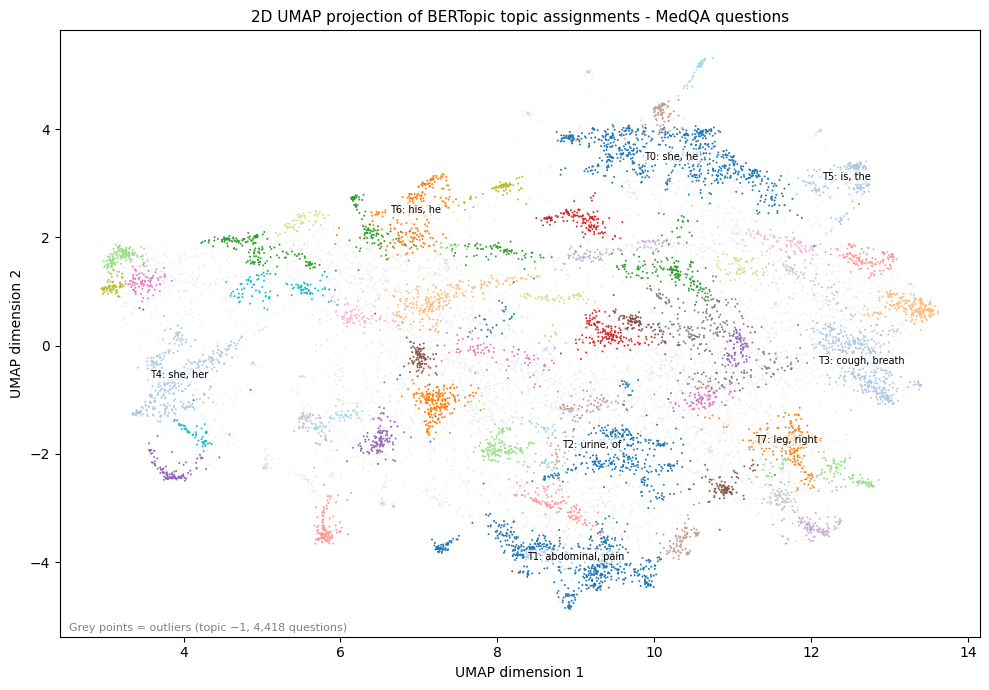

In [19]:
# 2D UMAP scatter of BERTopic topics
from umap import UMAP
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Reduce to 2D for visualization (separate from the 5D used for clustering)
umap_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.1,
               metric='cosine', random_state=42)
emb_2d = umap_2d.fit_transform(embeddings)

# Assign colors — outliers (-1) get grey
unique_topics = sorted(set(topics))
n_topics_plot = len([t for t in unique_topics if t != -1])
cmap = cm.get_cmap('tab20', n_topics_plot)
topic_to_color = {t: cmap(i) for i, t in enumerate(t for t in unique_topics if t != -1)}
topic_to_color[-1] = (0.8, 0.8, 0.8, 0.3)  # grey, transparent

colors = [topic_to_color[t] for t in topics]

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=colors, s=2, linewidths=0)

# Label the 8 largest non-outlier topics by centroid
topic_arr = np.array(topics)
top8 = sorted([t for t in unique_topics if t != -1],
              key=lambda t: list(topics).count(t), reverse=True)[:8]

topic_info = topic_model.get_topic_info()
for t in top8:
    mask_t = topic_arr == t
    cx, cy = emb_2d[mask_t, 0].mean(), emb_2d[mask_t, 1].mean()
    # Get top 2 words for label
    words = [w for w, _ in topic_model.get_topic(t)][:2]
    ax.annotate(f"T{t}: {', '.join(words)}", (cx, cy),
                fontsize=7, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, lw=0))

ax.set_title('2D UMAP projection of BERTopic topic assignments - MedQA questions', fontsize=11)
ax.set_xlabel('UMAP dimension 1')
ax.set_ylabel('UMAP dimension 2')
ax.text(0.01, 0.01, f'Grey points = outliers (topic −1, {topics.count(-1):,} questions)',
        transform=ax.transAxes, fontsize=8, color='grey')
plt.tight_layout()
plt.show()

## 6. Results Comparison

In [10]:
comparison_df = pd.DataFrame([
    {
        'Method':         'TF-IDF + GMM',
        'Type':           'A2 baseline',
        'K':              K,
        'Outliers':       '0 (0%)',
        "Cohen's kappa":  res_gmm['kappa'],
        'Silhouette':     res_gmm['silhouette'],
        'C_v':            res_gmm['coherence_cv'],
        'A2 kappa (ref)': 0.418,
    },
    {
        'Method':         'Embeddings + Spectral',
        'Type':           'A2 baseline',
        'K':              K,
        'Outliers':       '0 (0%)',
        "Cohen's kappa":  res_spectral['kappa'],
        'Silhouette':     res_spectral['silhouette'],
        'C_v':            res_spectral['coherence_cv'],
        'A2 kappa (ref)': 'N/A',
    },
    {
        'Method':         'BERTopic',
        'Type':           'Primary method',
        'K':              res_bertopic['n_topics'],
        'Outliers':       f"{res_bertopic['n_outliers']} ({res_bertopic['outlier_pct']}%)",
        "Cohen's kappa":  res_bertopic['kappa'],
        'Silhouette':     res_bertopic['silhouette'],
        'C_v':            res_bertopic['coherence_cv'],
        'A2 kappa (ref)': 'N/A',
    },
])
display(comparison_df)

,Method,Type,K,Outliers,Cohen's kappa,Silhouette,C_v,A2 kappa (ref)
0,TF-IDF + GMM,A2 baseline,19,0 (0%),-0.0193,NaN,NaN,0.418
1,Embeddings + Spectral,A2 baseline,19,0 (0%),-0.0192,0.0605,NaN,N/A
2,BERTopic,Primary method,55,4418 (34.7%),-0.0117,0.0690,0.5088,N/A


## 7. BERTopic Visualisations

In [11]:
# Top-word barchart for 8 largest topics
topic_model.visualize_barchart(top_n_topics=8, n_words=8)

In [12]:
# Topic similarity heatmap
n_show = min(30, res_bertopic['n_topics'])
topic_model.visualize_heatmap(n_clusters=n_show)

In [13]:
# Topic-specialty alignment — qualitative validation
alignment_df = topic_specialty_alignment(topics, specialties, topic_model)
print('Topic-specialty alignment (top 20 topics by size):')
display(alignment_df.head(20))

Topic-specialty alignment (top 20 topics by size):


,topic_id,top_words,dominant_specialty,specialty_pct,size
0,0,"she, he, to, patient, and",Psychiatry,50.3,682
1,1,"abdominal, pain, is, and, the",Internal Medicine,38.3,645
2,2,"urine, of, the, urinary, is",Internal Medicine,34.6,463
3,3,"cough, breath, of, chest, he",Internal Medicine,65.3,447
4,4,"she, her, menstrual, vaginal, pelvic",Obstetrics & Gynaecology,62.5,411
5,5,"is, the, vehicle, emergency, and",Surgery,38.1,236
6,6,"his, he, mother, parents, boy",Psychiatry,29.3,229
7,7,"leg, right, left, pain, the",Internal Medicine,51.8,228
8,8,"rash, skin, on, the, lesions",Internal Medicine,33.2,226
9,9,"boy, is, his, the, and",Pathology,36.0,225


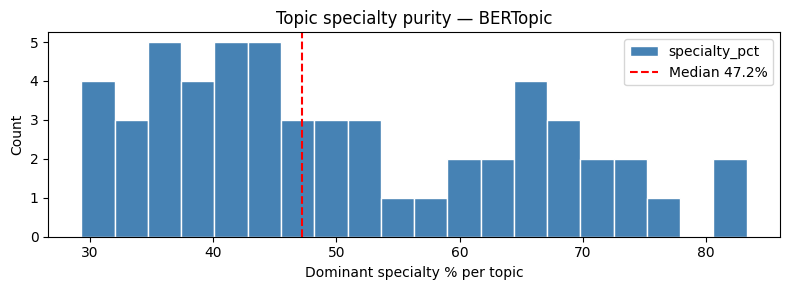

Higher purity -> topics align well with known specialties.


In [14]:
# Specialty purity distribution
fig, ax = plt.subplots(figsize=(8, 3))
alignment_df['specialty_pct'].plot(
    kind='hist', bins=20, ax=ax, color='steelblue', edgecolor='white'
)
med = alignment_df['specialty_pct'].median()
ax.axvline(med, color='red', linestyle='--', label=f'Median {med:.1f}%')
ax.set_xlabel('Dominant specialty % per topic')
ax.set_ylabel('Count')
ax.set_title('Topic specialty purity — BERTopic')
ax.legend()
plt.tight_layout()
plt.show()
print('Higher purity -> topics align well with known specialties.')

## 8. Save Outputs

In [15]:
# Attach topic assignments
medqa['topic'] = topics

out_path = CLUSTERING_DIR / 'medqa_with_topics.parquet'
medqa[['question', 'options', 'answer_idx', 'answer', 'split', 'specialty', 'topic']].to_parquet(
    out_path, index=False
)
print(f'Saved -> {out_path}  ({out_path.stat().st_size/1024:.0f} KB)')

# BERTopic model
model_path = CLUSTERING_DIR / 'bertopic_model'
topic_model.save(str(model_path), serialization='pickle')
print(f'Saved -> {model_path}')

# Config
config = {
    'embedding_model': EMB_MODEL,
    'n_questions':     len(medqa),
    'n_specialties':   K,
    'bertopic':  {
        'n_topics':     res_bertopic['n_topics'],
        'n_outliers':   res_bertopic['n_outliers'],
        'outlier_pct':  res_bertopic['outlier_pct'],
        'kappa':        res_bertopic['kappa'],
        'silhouette':   res_bertopic['silhouette'],
        'coherence_cv': res_bertopic['coherence_cv'],
    },
    'tfidf_gmm': {'kappa': res_gmm['kappa'], 'a2_baseline': 0.418},
    'spectral':  {'kappa': res_spectral['kappa'], 'silhouette': res_spectral['silhouette']},
}
with open(CLUSTERING_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'Saved -> {CLUSTERING_DIR / "config.json"}')

2026-04-14 15:56:14,983 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved -> C:\Projects\emma\models\clustering\medqa_with_topics.parquet  (6108 KB)
Saved -> C:\Projects\emma\models\clustering\bertopic_model
Saved -> C:\Projects\emma\models\clustering\config.json


In [16]:
# Copy outputs to Drive if on Colab
if IN_COLAB:
    import shutil

    DRIVE_OUT.mkdir(parents=True, exist_ok=True)

    for f in CLUSTERING_DIR.glob('*'):
        dest = DRIVE_OUT / f.name
        if f.is_dir():
            shutil.copytree(f, dest, dirs_exist_ok=True)
            print(f'  {f.name}/  -> Drive')
        else:
            shutil.copy(f, dest)
            print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB) -> Drive')

    print(f'✓ Done! Drive path: {DRIVE_OUT}')

## 9. Summary

In [17]:
config = json.loads((CLUSTERING_DIR / 'config.json').read_text())
bt = config['bertopic']
gm = config['tfidf_gmm']
sp = config['spectral']

summary_df = pd.DataFrame([
    {'Item': 'Questions clustered',       'Value': f"{config['n_questions']:,}"},
    {'Item': 'Specialties (ground truth)', 'Value': str(config['n_specialties'])},
    {'Item': 'Embedding model',           'Value': config['embedding_model']},
    {'Item': 'BERTopic K (auto)',         'Value': str(bt['n_topics'])},
    {'Item': 'BERTopic outliers',         'Value': f"{bt['n_outliers']:,}  ({bt['outlier_pct']}%)"},
    {'Item': 'BERTopic kappa',            'Value': str(bt['kappa'])},
    {'Item': 'BERTopic silhouette',       'Value': str(bt['silhouette'])},
    {'Item': 'BERTopic C_v coherence',    'Value': str(bt['coherence_cv'])},
    {'Item': 'TF-IDF + GMM kappa',        'Value': f"{gm['kappa']}  (A2 ref: {gm['a2_baseline']})"},
    {'Item': 'Spectral kappa',            'Value': str(sp['kappa'])},
    {'Item': 'Model saved',               'Value': str(CLUSTERING_DIR / 'bertopic_model')},
])

display(summary_df)

,Item,Value
0,Questions clustered,"12,723"
1,Specialties (ground truth),19
2,Embedding model,all-MiniLM-L12-v2
3,BERTopic K (auto),55
4,BERTopic outliers,"4,418 (34.7%)"
5,BERTopic kappa,-0.0117
6,BERTopic silhouette,0.069
7,BERTopic C_v coherence,0.5088
8,TF-IDF + GMM kappa,-0.0193 (A2 ref: 0.418)
9,Spectral kappa,-0.0192


<div class="alert alert-block alert-info">
Next > Notebook 04: RAG Pipeline
</div>